# Intel Image Classification — Baseline CNN

## Project Objective

Build a **baseline Convolutional Neural Network (CNN)** to classify natural scene images into six categories:

- `buildings`
- `forest`
- `glacier`
- `mountain`
- `sea`
- `street`

This notebook establishes the **baseline model** that will be used as the reference point for the improvement experiments in the second notebook.

### Workflow

1. Import the required libraries
2. Explore the dataset and class distribution
3. Inspect representative images and image dimensions
4. Prepare training, validation, and test datasets
5. Normalize image pixel values
6. Build the baseline CNN using convolution, pooling, and dense layers
7. Train the model for 10 epochs
8. Analyze training and validation performance
9. Evaluate the model on the independent test set
10. Inspect the confusion matrix

> **Baseline principle:** no additional CNN tricks or regularization techniques are introduced here. The purpose of this notebook is to provide a clean and fair reference model for later experiments.

## 1. Import Required Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

## 2. Dataset Paths

The dataset is organized into separate directories for training, testing, and prediction images.

In [2]:
train_dir = "seg_train"
test_dir = "seg_test"
pred_dir = "seg_pred"

print("Training directory:", train_dir)
print("Testing directory:", test_dir)
print("Prediction directory:", pred_dir)

Training directory: seg_train
Testing directory: seg_test
Prediction directory: seg_pred


## 3. Dataset Classes and Class Distribution

The class names are detected directly from the training-directory structure so that the notebook does not depend on manually entered folder names.

In [3]:
class_names = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6


In [4]:
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    image_count = len([
        file for file in os.listdir(class_path)
        if os.path.isfile(os.path.join(class_path, file))
    ])

    print(f"{class_name:12} : {image_count} images")

buildings    : 2191 images
forest       : 2271 images
glacier      : 2404 images
mountain     : 2512 images
sea          : 2274 images
street       : 2382 images


### Class Distribution

A quick visual check helps confirm that all six scene categories are represented in the training data.

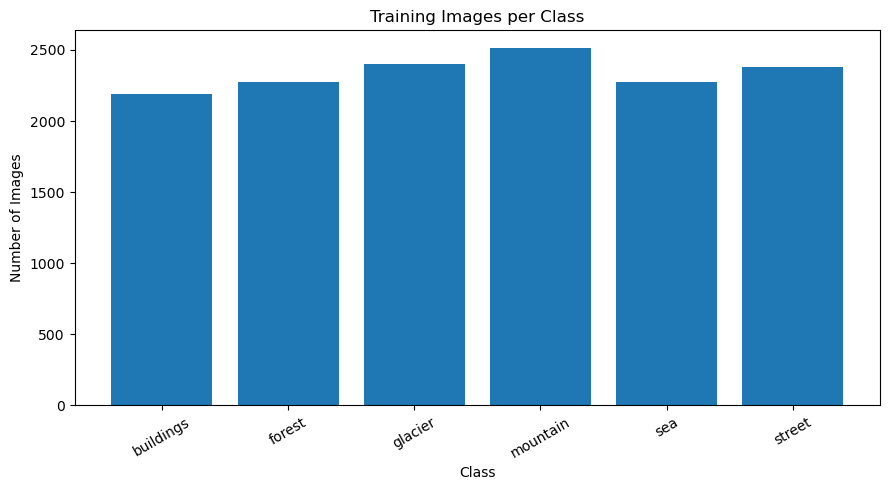

In [5]:
image_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    image_counts[class_name] = len([
        file for file in os.listdir(class_path)
        if os.path.isfile(os.path.join(class_path, file))
    ])

plt.figure(figsize=(9, 5))
plt.bar(image_counts.keys(), image_counts.values())

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Training Images per Class")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 4. Visual Inspection of the Dataset

One representative image from each class is displayed to verify that the folder labels correspond to the visual content of the images.

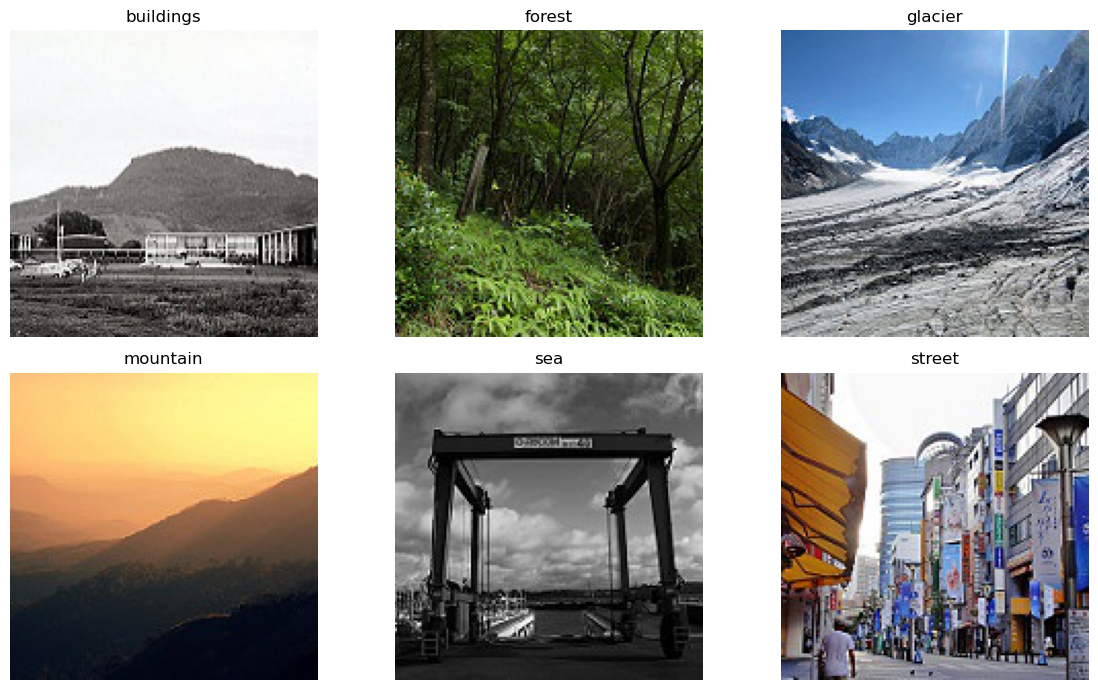

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for ax, class_name in zip(axes.ravel(), class_names):
    class_path = os.path.join(train_dir, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if os.path.isfile(os.path.join(class_path, file))
    ]

    image_path = os.path.join(class_path, image_files[0])
    image = plt.imread(image_path)

    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Image Dimensions

The dataset images are checked before loading to determine whether resizing will be necessary.

In [7]:
from PIL import Image

sample_sizes = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if os.path.isfile(os.path.join(class_path, file))
    ]

    # Check a few images from each class
    for file in image_files[:5]:
        image_path = os.path.join(class_path, file)
        with Image.open(image_path) as image:
            sample_sizes.append(image.size)

print("Sample image sizes:", sample_sizes[:10])
print("Unique sizes found:", set(sample_sizes))

Sample image sizes: [(150, 150), (150, 150), (150, 150), (150, 150), (150, 150), (150, 150), (150, 150), (150, 150), (150, 150), (150, 150)]
Unique sizes found: {(150, 150)}


## 6. Load Images into TensorFlow Datasets

Images are resized to **150 × 150 pixels** and grouped into batches of **32**. Categorical labels are used because this is a six-class classification problem.

In [8]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=42
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


In [9]:
print("Class names:", train_dataset.class_names)
print("Number of classes:", len(train_dataset.class_names))

Class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6


## 7. Training / Validation / Test Split

The original training directory is divided into:

- **90% training data**
- **10% validation data**

The separate `seg_test` directory remains untouched and is used only for final evaluation.

In [10]:
VAL_SPLIT = 0.1

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    validation_split=VAL_SPLIT,
    subset="training",
    shuffle=True,
    seed=42
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    validation_split=VAL_SPLIT,
    subset="validation",
    shuffle=False,
    seed=42
)

Found 14034 files belonging to 6 classes.
Using 12631 files for training.
Found 14034 files belonging to 6 classes.
Using 1403 files for validation.


In [11]:
print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

Training batches: 395
Validation batches: 44
Test batches: 94


## 8. Image Preprocessing

Pixel values are rescaled from the range **0–255** to **0–1**. The same preprocessing is applied consistently to training, validation, and test datasets.

In [12]:
normalization_layer = layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

val_dataset = val_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

test_dataset = test_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

### Input Pipeline Optimization

`prefetch()` allows TensorFlow to prepare the next batch while the current batch is being processed. This improves the input pipeline without changing the model itself.

In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

## 9. Baseline CNN Architecture

The baseline follows the standard CNN structure discussed in the lecture:

**Convolution → Pooling → Convolution → Pooling → Convolution → Flatten → Dense → Output**

No Batch Normalization, Dropout, Residual Blocks, or Global Pooling are used in this baseline. Keeping the architecture simple gives us a reliable reference for later experiments.

In [14]:
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(6)
])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 73984)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     4,735,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,791,750 (18.28 MB)

 Trainable params: 4,791,750 (18.28 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Compile the Model

The model uses:

- **Adam** optimizer
- **Categorical Cross-Entropy** loss
- **Accuracy** as the evaluation metric

`from_logits=True` is used because the final layer outputs raw logits rather than applying Softmax directly.

In [16]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

## 11. Train the Baseline Model

The baseline model is trained for **10 epochs** using the training dataset and monitored on the validation dataset.

In [17]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10


C:\Users\mhmwd\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


395/395 ━━━━━━━━━━━━━━━━━━━━ 150s 370ms/step - accuracy: 0.6322 - loss: 0.9487 - val_accuracy: 0.8239 - val_loss: 0.5019
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 145s 366ms/step - accuracy: 0.7736 - loss: 0.6299 - val_accuracy: 0.8133 - val_loss: 0.4681
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 144s 364ms/step - accuracy: 0.8294 - loss: 0.4625 - val_accuracy: 0.9252 - val_loss: 0.2367
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 143s 362ms/step - accuracy: 0.8892 - loss: 0.3149 - val_accuracy: 0.9558 - val_loss: 0.1627
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 142s 360ms/step - accuracy: 0.9315 - loss: 0.1987 - val_accuracy: 0.9465 - val_loss: 0.2049
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 143s 361ms/step - accuracy: 0.9546 - loss: 0.1310 - val_accuracy: 0.9658 - val_loss: 0.1488
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 145s 366ms/step - accuracy: 0.9694 - loss: 0.0950 - val_accuracy: 0.9850 - val_loss: 0.1073
Epoch 8/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 145s 366ms/step - accuracy: 0.9784 - loss: 0.06

## 12. Training Performance

The learning curves show how the model learns over the 10 training epochs and help identify differences between training and validation behavior.

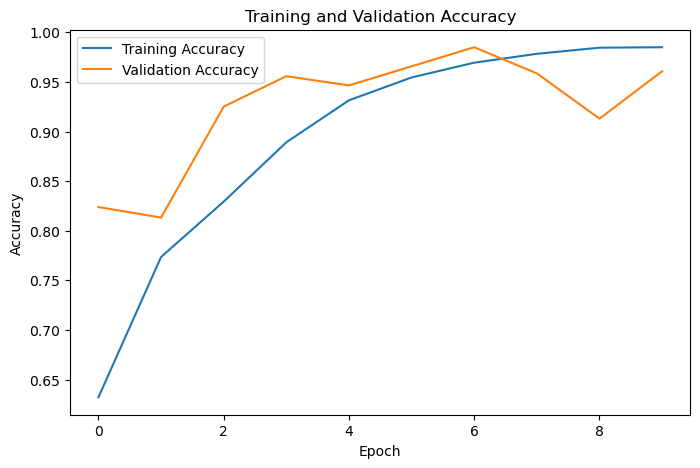

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

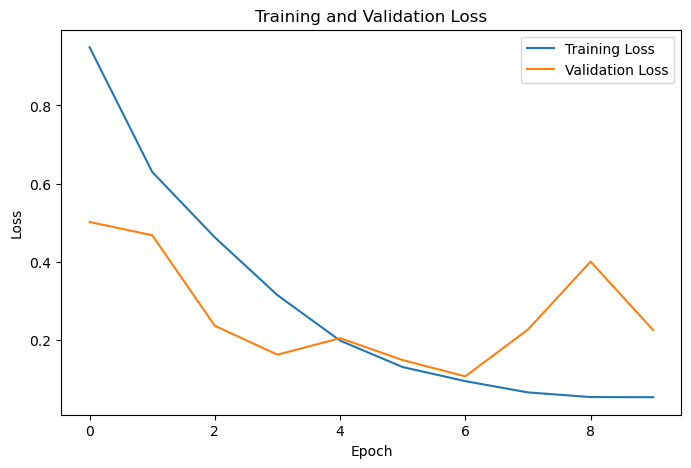

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

## 13. Final Test Evaluation

The test set is evaluated only after training. This provides the final performance of the baseline model on images that were not used during training or validation.

In [20]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.7520 - loss: 1.4091
Test Loss: 1.4091
Test Accuracy: 0.7520


## 14. Confusion Matrix

Accuracy gives one overall performance number, while the confusion matrix shows **which scene categories are being confused with one another**.

This is especially useful for comparing the baseline with the improved models in the second notebook.

In [21]:
from sklearn.metrics import confusion_matrix

class_names = [
    'buildings',
    'forest',
    'glacier',
    'mountain',
    'sea',
    'street'
]

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm_baseline = confusion_matrix(y_true, y_pred)

print("Baseline Confusion Matrix:")
print(cm_baseline)

Baseline Confusion Matrix:
[[326   5   7  10  20  69]
 [ 13 412   2   5   1  41]
 [ 20   3 372 110  40   8]
 [ 18   3  62 387  52   3]
 [ 21   2  30  66 380  11]
 [ 87  12   7   5  11 379]]


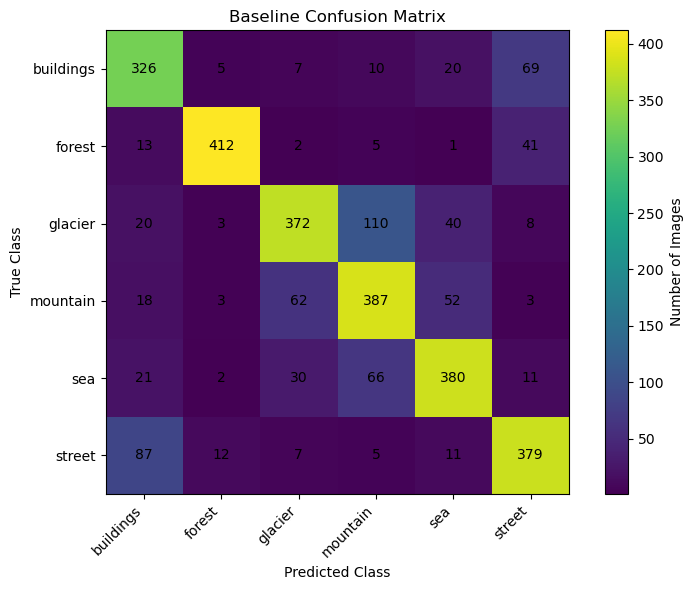

In [22]:
plt.figure(figsize=(8, 6))

plt.imshow(cm_baseline)

plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

for i in range(len(cm_baseline)):
    for j in range(len(cm_baseline)):
        plt.text(
            j, i, cm_baseline[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(label="Number of Images")
plt.tight_layout()
plt.show()

## 15. Baseline Conclusion

This notebook establishes the **reference CNN model** for the project.

The baseline provides:

- A clear and reproducible CNN pipeline
- Consistent image preprocessing
- A fixed train/validation/test evaluation procedure
- Training and validation learning curves
- A final test-set accuracy
- A confusion matrix for class-level error analysis

The resulting test performance is treated as the **baseline benchmark**. Any improvement introduced in the second notebook should be compared against this result rather than judged only from training or validation accuracy.

### Next Step

The second notebook explores selected CNN techniques from the lecture and compares their test performance against this baseline.